### Importing librabries

In [262]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Load Dataset

In [263]:
df = sns.load_dataset("titanic")
df.head(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


### Data Cleaning

In [264]:
df.shape

(891, 15)

In [265]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [266]:
print(df.duplicated().sum())

107


### Handle Missing Values

In [267]:
## Fill missing age values based on passenger class median
df["age"] = df.groupby("pclass")["age"].transform(lambda x: x.fillna(x.median()))

df["age_group"] = pd.cut(df["age"], bins=[0,12,20,40,60,80],
                        labels=["child","teen","adult","mid","old"])


df["embarked"].fillna(df["embarked"].mode()[0], inplace=True)

C:\Users\ninga\AppData\Local\Temp\ipykernel_5036\1456917235.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["embarked"].fillna(df["embarked"].mode()[0], inplace=True)


In [268]:
df['survived'].value_counts()

survived
0    549
1    342
Name: count, dtype: int64

### Data Visualisation

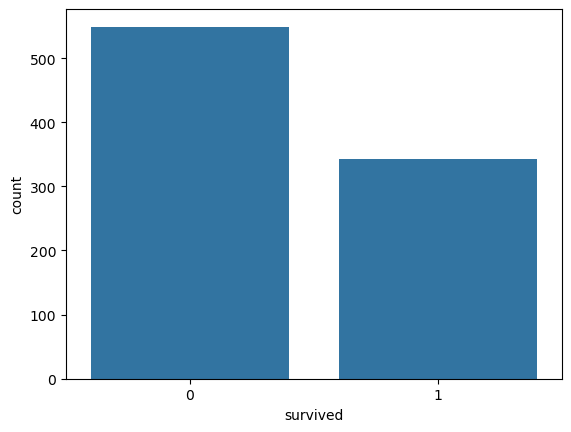

In [269]:
sns.countplot(x="survived", data=df)
plt.show()


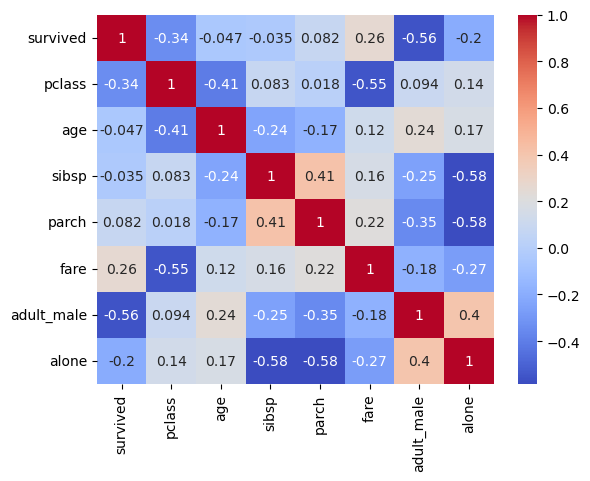

In [270]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()


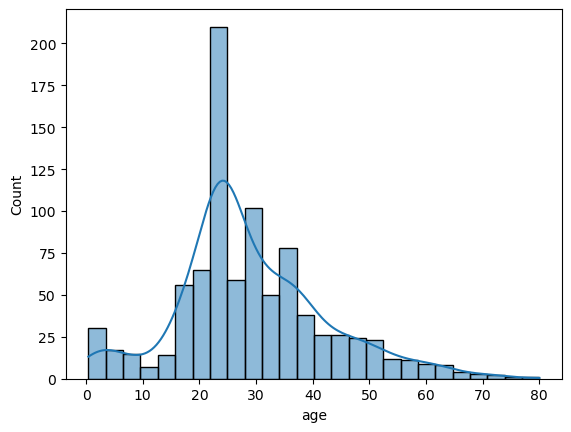

In [271]:
sns.histplot(df['age'], kde=True)
plt.show()


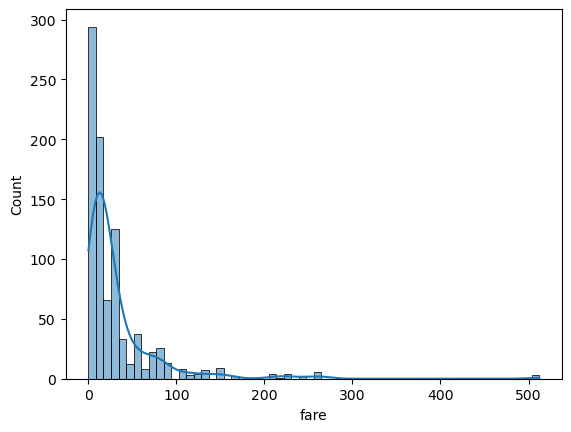

In [272]:
sns.histplot(df['fare'], kde=True)
plt.show()


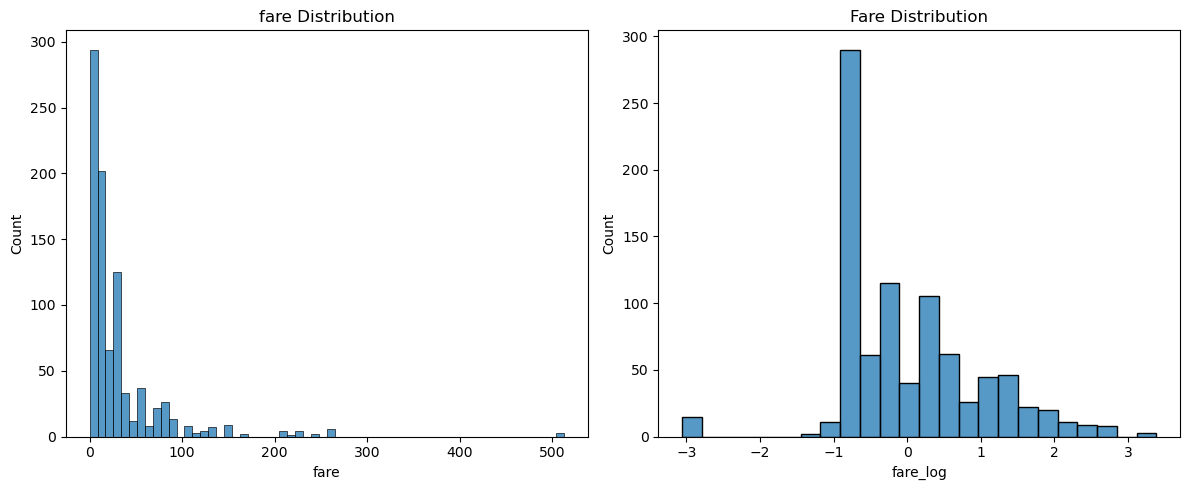

In [280]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df["fare"], ax=axes[0])
axes[0].set_title("fare Distribution")

# Second histogram
sns.histplot(df["fare_log"], ax=axes[1])
axes[1].set_title("Fare Distribution")

plt.tight_layout()
plt.show()

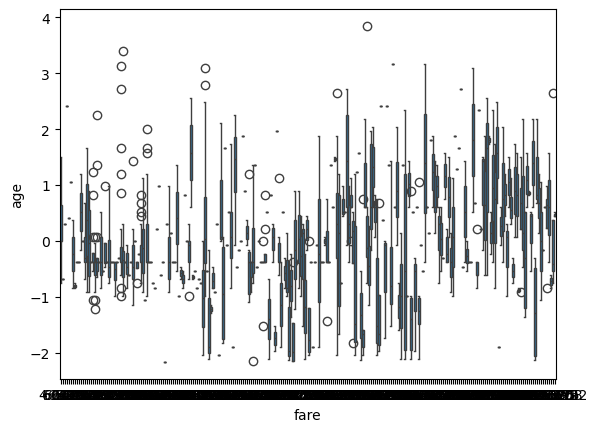

In [281]:
sns.boxplot(x="fare", y="age", data=df)
plt.show()

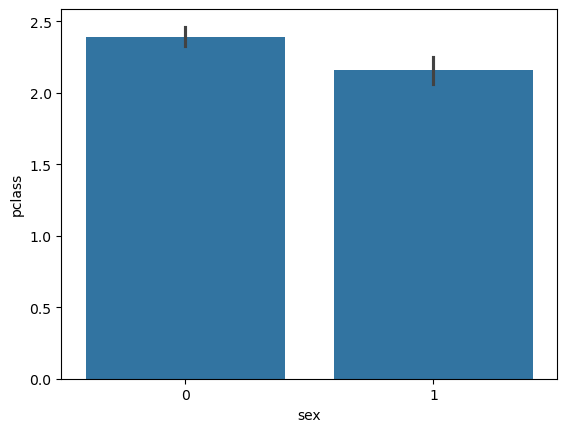

In [282]:
sns.barplot(x="sex", y="pclass", data=df)
plt.show()

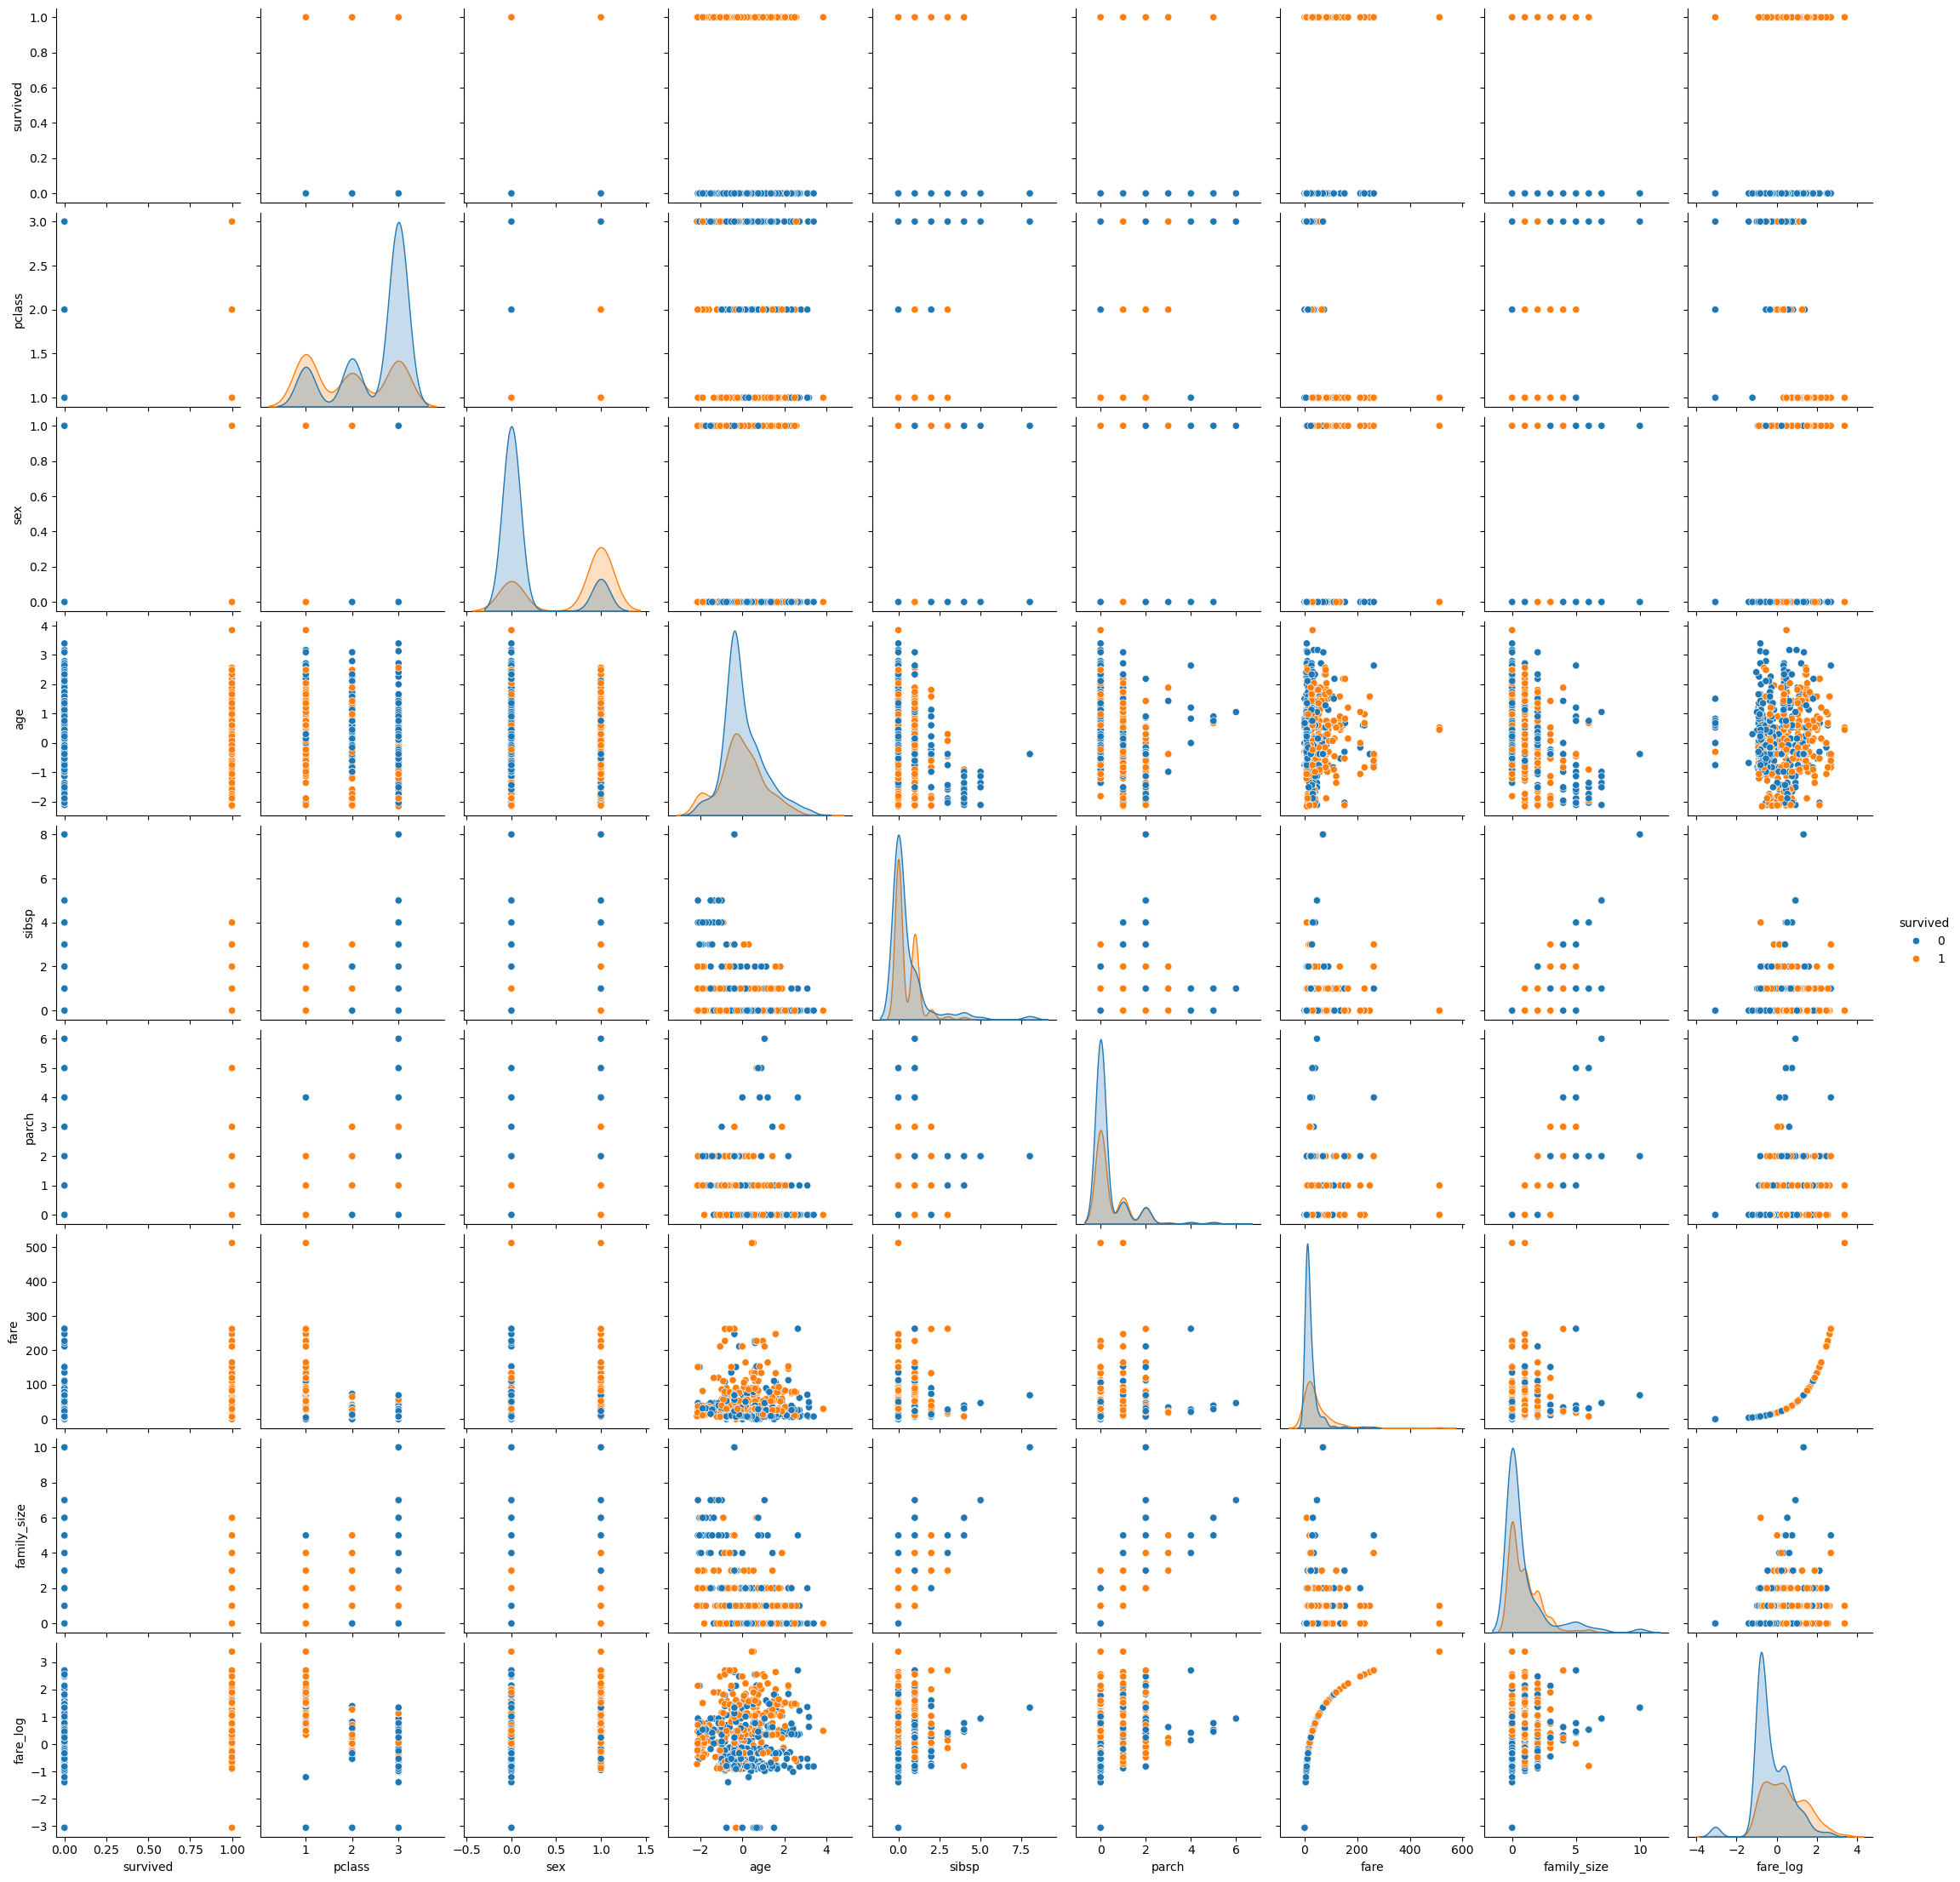

In [283]:
num_cols = df.select_dtypes(include='number').columns

sns.pairplot(df, vars=num_cols, hue="survived")
plt.show()

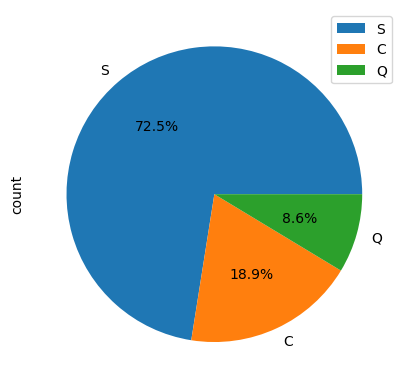

In [284]:
df["embarked"].value_counts().plot.pie(autopct="%1.1f%%")
plt.legend()
plt.show()


### Encoding

In [ ]:
df = pd.get_dummies(df, columns=["embarked"])

In [274]:
df['sex'] = df['sex'].map({'male':0,'female':1})

### Feature Engineering

In [275]:
df["is_rich"] = df["fare"] > df["fare"].median()

df["family_size"] = df["sibsp"] + df["parch"]

df["fare_log"] = np.log1p(df["fare"])

### Scaling

In [276]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

cols = ['age', 'fare_log']
df[cols] = scaler.fit_transform(df[cols])

### Removing unnecesaary data

In [277]:
df.drop(columns=['deck','embark_town','alive','class','who','age_group'], inplace=True)

In [285]:
df.to_csv("cleaned_titanic.csv", index=False)

In [286]:
df = pd.read_csv("cleaned_titanic.csv")

In [287]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,adult_male,alone,is_rich,family_size,fare_log
0,0,3,0,-0.533834,1,0,7.2500,S,True,False,False,1,-0.879741
1,1,1,1,0.674891,1,0,71.2833,C,False,False,True,1,1.361220
2,1,3,1,-0.231653,0,0,7.9250,S,False,True,False,0,-0.798540
3,1,1,1,0.448255,1,0,53.1000,S,False,False,True,1,1.062038
4,0,3,0,0.448255,0,0,8.0500,S,True,True,False,0,-0.784179


In [288]:
df.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
adult_male     0
alone          0
is_rich        0
family_size    0
fare_log       0
dtype: int64